In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/laingangiang/Downloads/mymoviedb (1).csv", encoding="latin-1", engine="python", header=0)

In [3]:
# Display the first 10 rows of the DataFrame
print(df.head(10))

  Release_Date                    Title  \
0   2021-12-15  Spider-Man: No Way Home   
1   2022-03-01               The Batman   
2   2022-02-25                  No Exit   
3   2021-11-24                  Encanto   
4   2021-12-22           The King's Man   
5   2022-01-07             The Commando   
6   2022-01-12                   Scream   
7   2022-02-10                     Kimi   
8   2022-02-17     Fistful of Vengeance   
9   2021-11-03                 Eternals   

                                            Overview  Popularity Vote_Count  \
0  Peter Parker is unmasked and no longer able to...    5083.954       8940   
1  In his second year of fighting crime, Batman u...    3827.658       1151   
2  Stranded at a rest stop in the mountains durin...    2618.087        122   
3  The tale of an extraordinary family, the Madri...    2402.201       5076   
4  As a collection of history's worst tyrants and...    1895.511       1793   
5  An elite DEA agent returns home after a failed...

In [4]:
# Display the last 10 rows of the DataFrame
print(df.tail(10))

     Release_Date                                 Title  \
9827   2005-05-18     I'm in Love With My Little Sister   
9828   2013-08-23                           All Is Lost   
9829   2008-05-13            Amateur Porn Star Killer 2   
9830   1992-06-26                        Unlawful Entry   
9831   1974-11-06                     The Little Prince   
9832   1973-10-15                              Badlands   
9833   2020-10-01                      Violent Delights   
9834   2016-05-06                          The Offering   
9835   2021-03-31  The United States vs. Billie Holiday   
9836   1984-09-23                               Threads   

                                               Overview  Popularity  \
9827  Yori and his twin sister Iku used to be very c...      13.360   
9828  During a solo voyage in the Indian Ocean, a ve...      13.359   
9829  Shane Ryan's sequel to the disturbing Amateur ...      13.359   
9830  After a break-in at their house, a couple gets...      13.35

In [5]:
# Remove rows and columns with missing values
df = df.dropna(axis=0)
df = df.dropna(axis=1)

In [6]:
# Display the data set summary about the DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 9826 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9826 non-null   object 
 1   Title              9826 non-null   object 
 2   Overview           9826 non-null   object 
 3   Popularity         9826 non-null   float64
 4   Vote_Count         9826 non-null   object 
 5   Vote_Average       9826 non-null   object 
 6   Original_Language  9826 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 767.7+ KB
None


In [7]:
# Display the statistical summary of the DataFrame
print(df.describe())

        Popularity
count  9826.000000
mean     40.323951
std     108.879332
min      13.354000
25%      16.128250
50%      21.195000
75%      35.179250
max    5083.954000


In [8]:
# Display the original data types of each column in the DataFrame
print(df.dtypes)

Release_Date          object
Title                 object
Overview              object
Popularity           float64
Vote_Count            object
Vote_Average          object
Original_Language     object
Genre                 object
Poster_Url            object
dtype: object


In [9]:
# Convert data type
df = df.astype({"Vote_Count": "int64"})
df = df.astype({"Vote_Average": "float64"})

In [10]:
# Display the data types of the "Vote_Count" and "Vote_Average" columns after conversion
print(df.dtypes[["Vote_Count", "Vote_Average"]])

Vote_Count        int64
Vote_Average    float64
dtype: object


In [11]:
# Define the ranges for Popularity
bins1 = np.linspace(df["Popularity"].min(), df["Popularity"].max(), 5)
labels1 = ["Low", "Moderate", "High", "Trending"]

In [12]:
# Define the ranges for Vote_Count
bins2 = np.linspace(df["Vote_Count"].min(), df["Vote_Count"].max(), 5)
labels2 = ["Niche", "Limited", "Popular", "Mainstream"]

In [13]:
# Define the ranges for Vote_Average
bins3 = np.linspace(df["Vote_Average"].min(), df["Vote_Average"].max(), 5)
labels3 = ["Poor", "Average", "Good", "Excellent"]

In [14]:
# Create new categorical columns based on the defined ranges
df["Popularity_Category"] = pd.cut(df["Popularity"], bins=bins1, labels=labels1)
df["Vote_Count_Category"] = pd.cut(df["Vote_Count"], bins=bins2, labels=labels2)
df["Vote_Average_Category"] = pd.cut(df["Vote_Average"], bins=bins3, labels=labels3)

In [15]:
# Convert the values in the Original_Language column to uppercase
df["Original_Language"] = df["Original_Language"].str.upper()

In [16]:
# Display the unique values in the "Original_Language" and "Genre" columns
print(df["Original_Language"].unique())
print(df["Genre"].str.split(", ").explode().unique())

['EN' 'JA' 'FR' 'HI' 'ES' 'RU' 'DE' 'TH' 'KO' 'TR' 'CN' 'ZH' 'IT' 'PT'
 'ML' 'PL' 'FI' 'NO' 'DA' 'ID' 'SV' 'NL' 'TE' 'SR' 'IS' 'RO' 'TL' 'FA'
 'UK' 'NB' 'EU' 'LV' 'AR' 'EL' 'CS' 'MS' 'BN' 'CA' 'LA' 'TA' 'HU' 'HE'
 'ET']
['Action' 'Adventure' 'Science Fiction' 'Crime' 'Mystery' 'Thriller'
 'Animation' 'Comedy' 'Family' 'Fantasy' 'War' 'Horror' 'Drama' 'Music'
 'Romance' 'Western' 'History' 'TV Movie' 'Documentary']


In [17]:
# Create dummy variables for "Original_Language" and "Genre" columns
original_language_dummies = pd.get_dummies(df["Original_Language"])
genre_dummies = pd.get_dummies(df["Genre"].str.split(", ").explode())

In [18]:
# Group the dummy variables by the original index to combine the multiple genres for each movie
grouped_genre_dummies = genre_dummies.groupby(genre_dummies.index).max()
grouped_language_dummies = original_language_dummies.groupby(original_language_dummies.index).max()

In [19]:
# Create pivot tables for genre and language analysis
genre_df = df.assign(Genre=df["Genre"].str.split(", ")).explode("Genre")

In [20]:
# Calculate average popularity by genre and language
average_popularity_by_genre = genre_df.pivot_table(index="Genre", values="Popularity", aggfunc="mean")

print("Average Popularity by Genre")
print(average_popularity_by_genre)

Average Popularity by Genre
                 Popularity
Genre                      
Action            50.890133
Adventure         53.742888
Animation         52.427663
Comedy            37.873669
Crime             44.747295
Documentary       29.235377
Drama             30.077651
Family            46.610616
Fantasy           53.081342
History           28.395827
Horror            38.264498
Music             33.771410
Mystery           40.093590
Romance           30.866030
Science Fiction   49.511334
TV Movie          29.954715
Thriller          42.946258
War               35.298075
Western           36.187912


In [21]:
# Calculate average popularity by language
average_popularity_by_language = df.pivot_table(index="Original_Language", values="Popularity", aggfunc="mean")

print("Average Popularity by Language")
print(average_popularity_by_language)

Average Popularity by Language
                   Popularity
Original_Language            
AR                  17.296000
BN                  18.059000
CA                  17.214000
CN                  23.140780
CS                  16.701500
DA                  22.421821
DE                  25.943000
EL                  16.509600
EN                  41.757115
ES                  37.969496
ET                  13.822000
EU                  21.859000
FA                  19.227667
FI                  39.041400
FR                  32.921370
HE                  14.743500
HI                  85.931654
HU                  14.394667
ID                  26.699533
IS                  24.312500
IT                  25.889862
JA                  40.723309
KO                  33.513265
LA                  17.138000
LV                  21.540000
ML                 151.512000
MS                  18.416000
NB                  22.410000
NL                  24.479238
NO                  27.515462
PL       

In [22]:
# Calculate movie count by genre and language
movie_count_by_genre = genre_df.pivot_table(index="Genre", values="Title", aggfunc="count").rename(columns={"Title": "Movie_Count"})

print("Movie Count by Genre")
print(movie_count_by_genre)

Movie Count by Genre
                 Movie_Count
Genre                       
Action                  2686
Adventure               1853
Animation               1438
Comedy                  3031
Crime                   1242
Documentary              215
Drama                   3744
Family                  1414
Fantasy                 1308
History                  427
Horror                  1470
Music                    295
Mystery                  773
Romance                 1476
Science Fiction         1273
TV Movie                 214
Thriller                2488
War                      308
Western                  137


In [23]:
# Calculate movie count by language
movie_count_by_language = df.pivot_table(index="Original_Language", values="Title", aggfunc="count").rename(columns={"Title": "Movie_Count"})

print("Movie Count by Language")
print(movie_count_by_language)

Movie Count by Language
                   Movie_Count
Original_Language             
AR                           2
BN                           1
CA                           1
CN                         109
CS                           4
DA                          28
DE                          82
EL                           5
EN                        7569
ES                         339
ET                           1
EU                           1
FA                           3
FI                           5
FR                         292
HE                           2
HI                          26
HU                           3
ID                          15
IS                           2
IT                         123
JA                         645
KO                         170
LA                           1
LV                           1
ML                           1
MS                           1
NB                           1
NL                          21
NO             

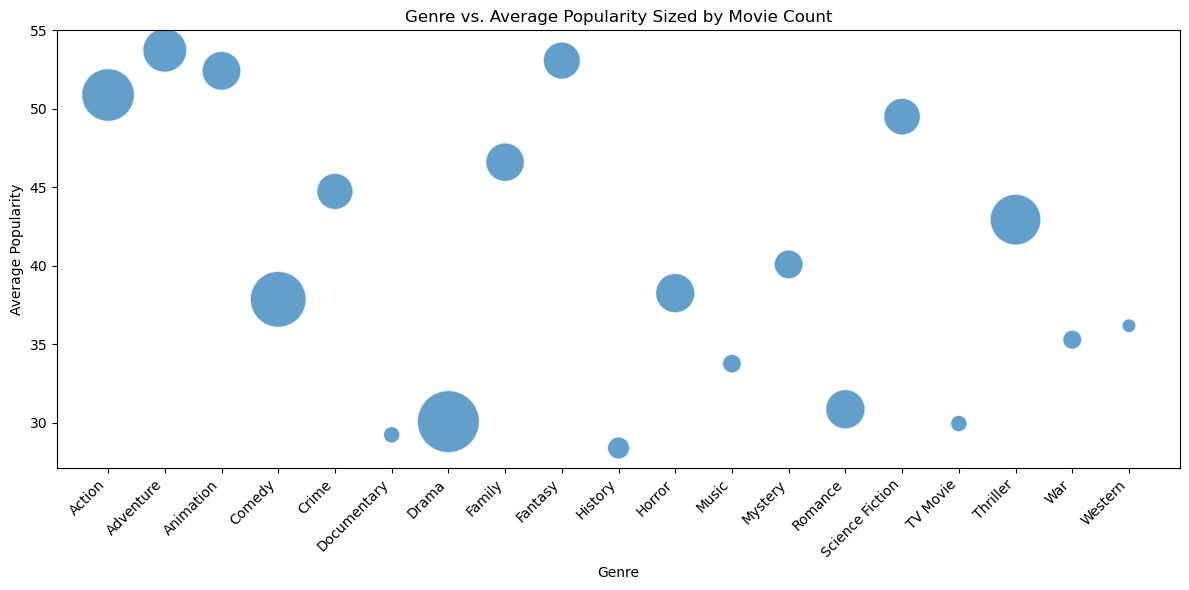

In [24]:
# Create a bubble chart for Genre vs. Average Popularity sized by movie count
genre_bubble_df = average_popularity_by_genre.join(movie_count_by_genre).reset_index()

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=genre_bubble_df,
    x="Genre",
    y="Popularity",
    size="Movie_Count",
    sizes=(100, 2000),
    legend=False,
    alpha=0.7,
    color="#1f77b4"
)
plt.title("Genre vs. Average Popularity Sized by Movie Count")
plt.xlabel("Genre")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
# Calculate average vote count by genre and language
average_vote_count_by_genre = genre_df.pivot_table(index="Genre", values="Vote_Count", aggfunc="mean")

print("Average Vote count by Genre")
print(average_vote_count_by_genre)

Average Vote count by Genre
                  Vote_Count
Genre                       
Action           1812.611690
Adventure        2328.045872
Animation        1060.507650
Comedy           1297.755526
Crime            1594.413043
Documentary       177.786047
Drama            1373.262553
Family           1447.400990
Fantasy          1928.088685
History          1234.323185
Horror            985.364626
Music            1008.291525
Mystery          1528.169470
Romance          1222.056911
Science Fiction  2239.179890
TV Movie          319.817757
Thriller         1459.643891
War              1457.525974
Western          1363.941606


In [26]:
# Calculate average vote count by language
average_vote_count_by_language = df.pivot_table(index="Original_Language", values="Vote_Count", aggfunc="mean")

print("Average Vote count by Language")
print(average_vote_count_by_language)

Average Vote count by Language
                    Vote_Count
Original_Language             
AR                  701.500000
BN                   18.000000
CA                   10.000000
CN                  314.422018
CS                  166.000000
DA                  424.142857
DE                  532.231707
EL                  465.600000
EN                 1687.513014
ES                  332.808260
ET                   55.000000
EU                  421.000000
FA                  405.333333
FI                   95.600000
FR                  667.969178
HE                   96.000000
HI                  382.384615
HU                  179.000000
ID                  388.733333
IS                  206.000000
IT                  698.764228
JA                  325.435659
KO                  464.629412
LA                  914.000000
LV                    0.000000
ML                  192.000000
MS                   55.000000
NB                 1239.000000
NL                  194.761905
NO      

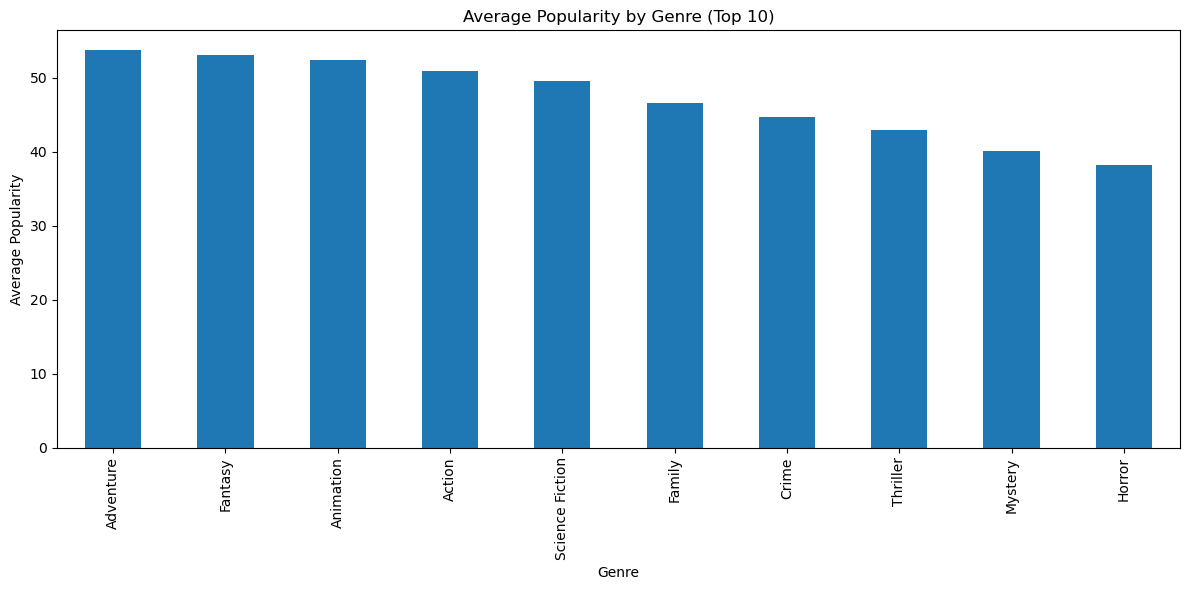

In [27]:
# Plot horizontal bar chart (sorted) for average popularity by genre
average_popularity_by_genre.sort_values("Popularity", ascending=False).head(10).plot(kind="bar", legend=False, figsize=(12, 6))

plt.title("Average Popularity by Genre (Top 10)")
plt.xlabel("Genre")
plt.ylabel("Average Popularity")
plt.tight_layout()
plt.show()

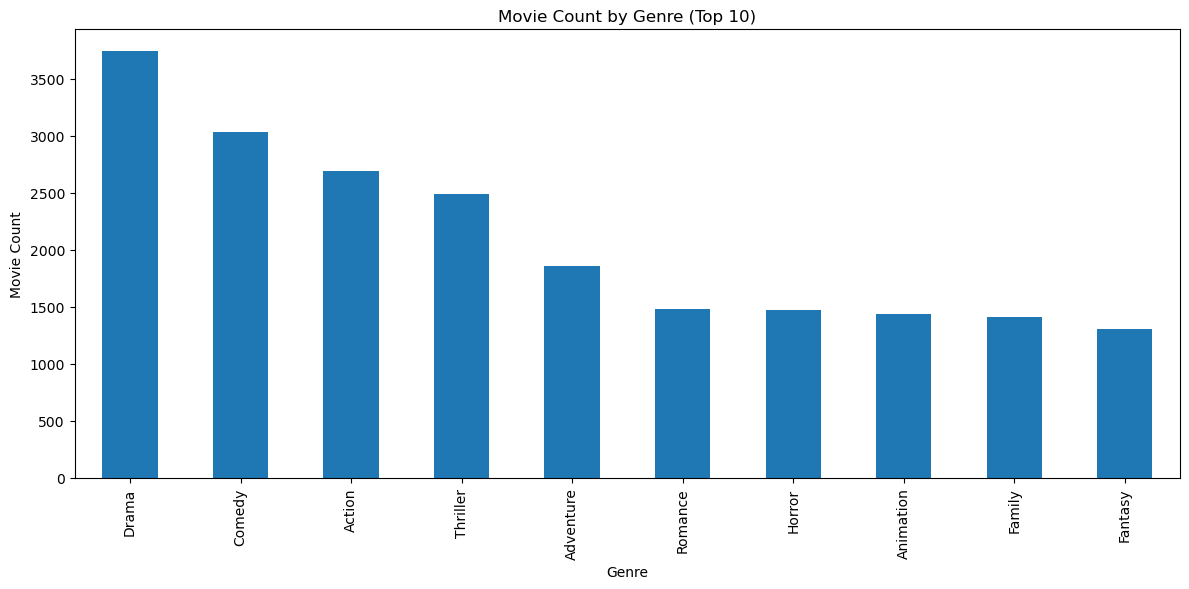

In [28]:
# Plot horizontal bar chart (sorted) for movie count by genre
movie_count_by_genre.sort_values("Movie_Count", ascending=False).head(10).plot(kind="bar", legend=False, figsize=(12, 6))

plt.title("Movie Count by Genre (Top 10)")
plt.xlabel("Genre")
plt.ylabel("Movie Count")
plt.tight_layout()
plt.show()

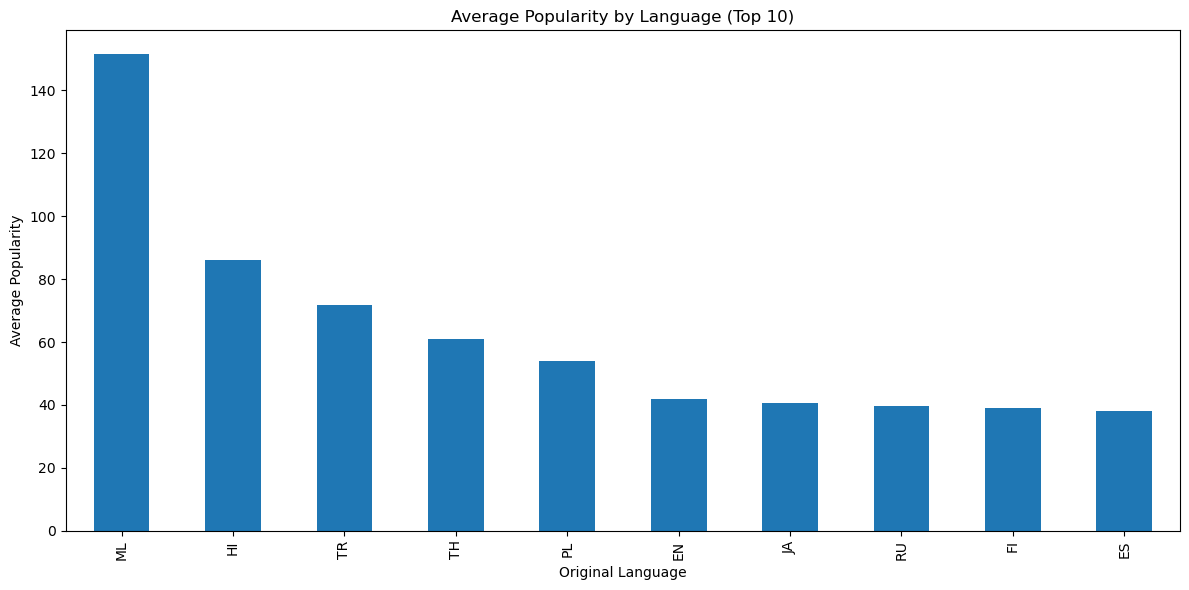

In [29]:
# Plot horizontal bar chart (sorted) for average popularity by language
average_popularity_by_language.sort_values("Popularity", ascending=False).head(10).plot(kind="bar", legend=False, figsize=(12, 6))

plt.title("Average Popularity by Language (Top 10)")
plt.xlabel("Original Language")
plt.ylabel("Average Popularity")
plt.tight_layout()
plt.show()

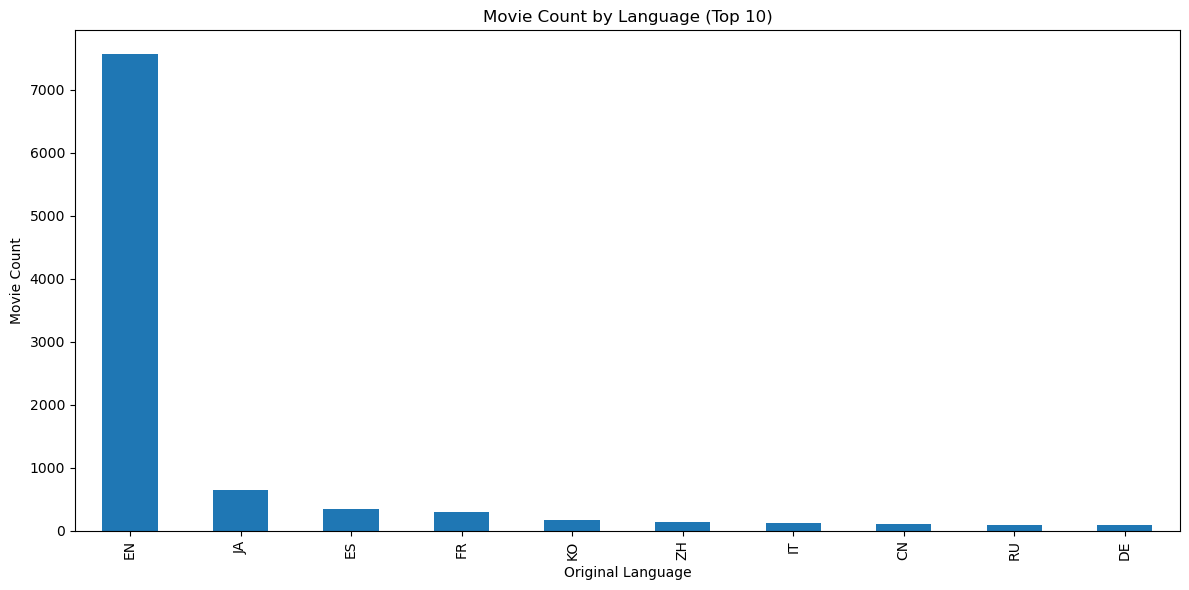

In [30]:
# Plot horizontal bar chart (sorted) for movie count by language
movie_count_by_language.sort_values("Movie_Count", ascending=False).head(10).plot(kind="bar", legend=False, figsize=(12, 6))

plt.title("Movie Count by Language (Top 10)")
plt.xlabel("Original Language")
plt.ylabel("Movie Count")
plt.tight_layout()
plt.show()

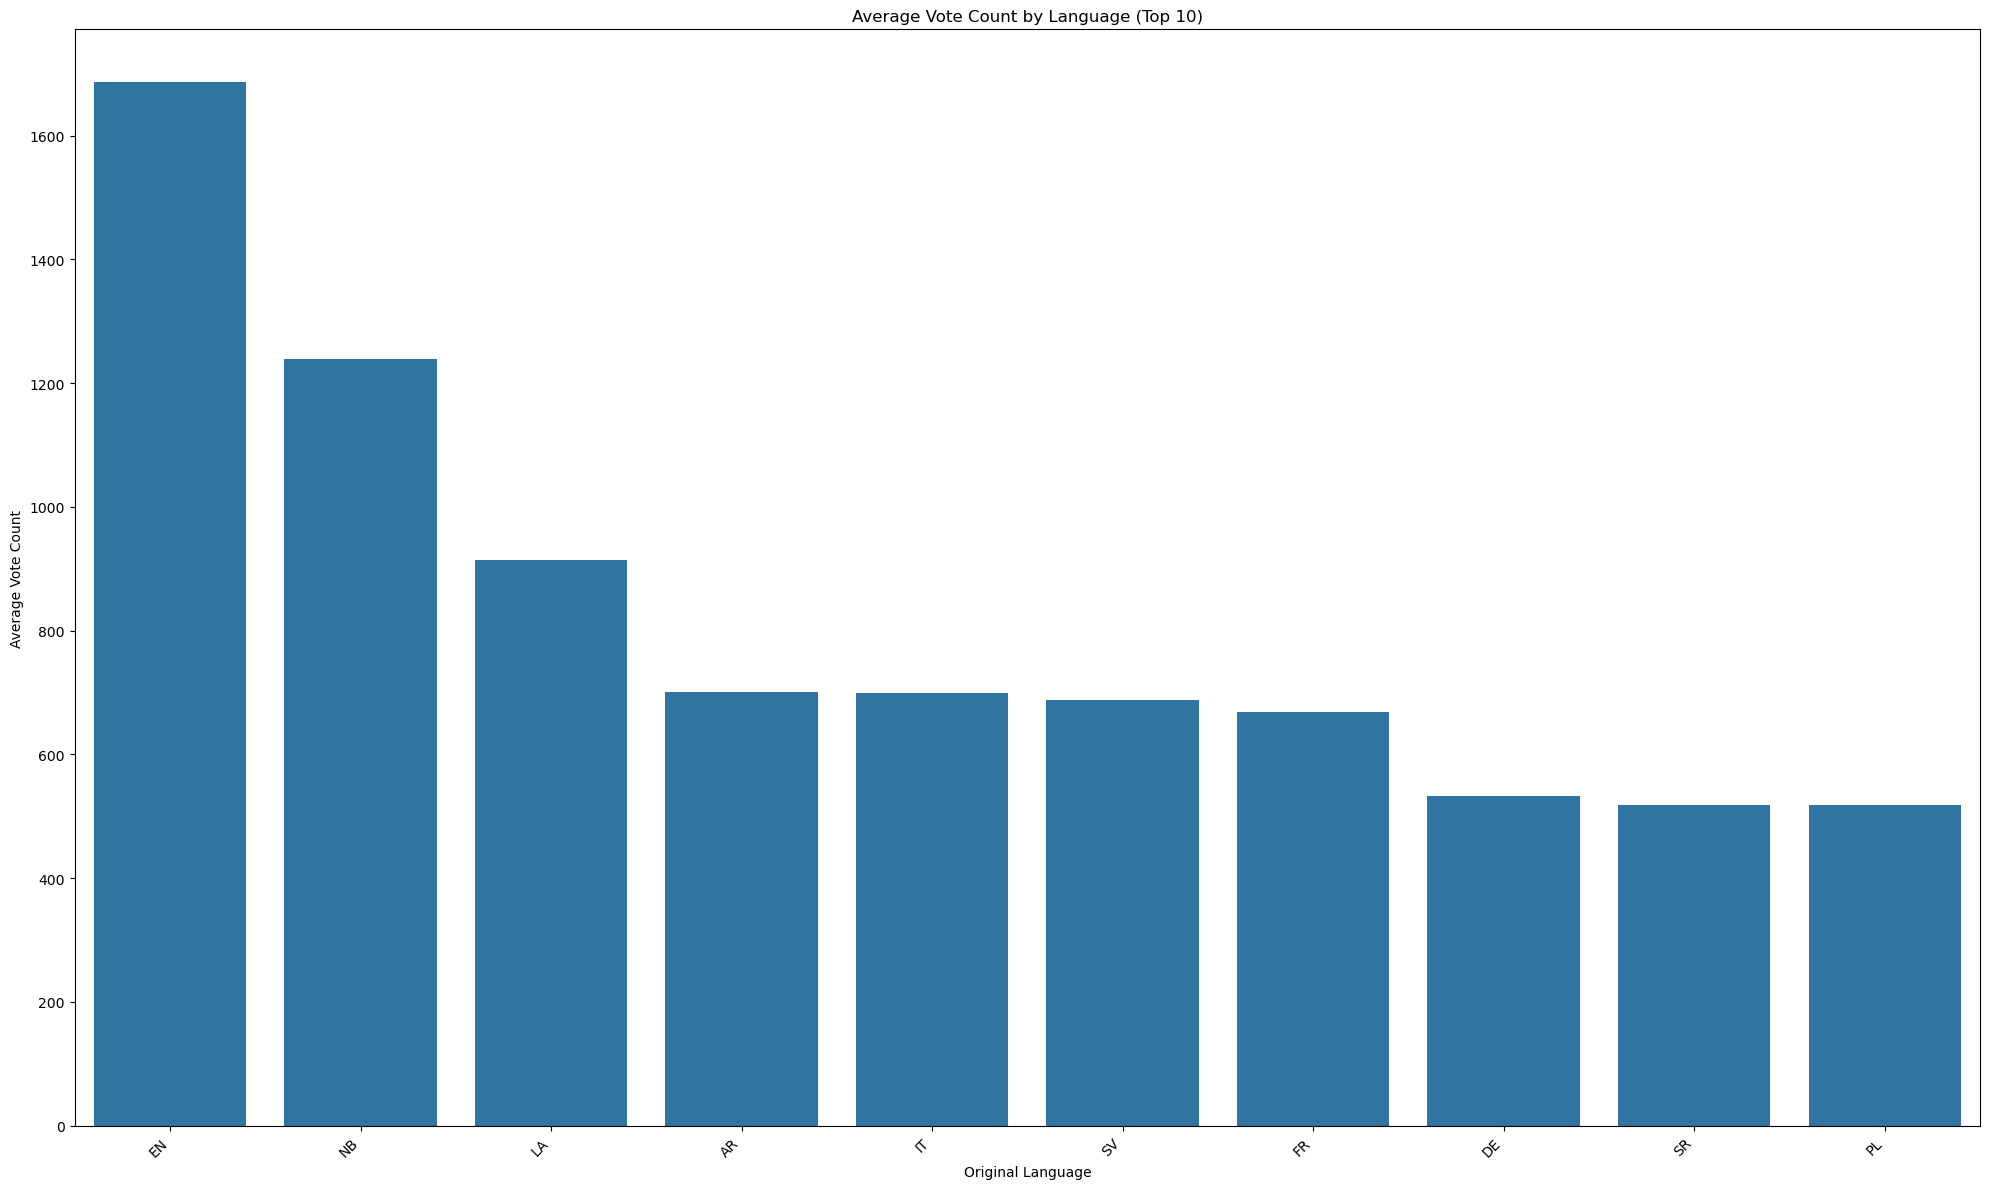

In [31]:
# Plot horizontal bar chart (sorted) for average vote count by language
avg_vote_lang_df = average_vote_count_by_language.reset_index().sort_values(by="Vote_Count", ascending=False).head(10)

plt.figure(figsize=(20, 12))
sns.barplot(x="Original_Language", y="Vote_Count", data=avg_vote_lang_df, color="#1f77b4")
plt.title("Average Vote Count by Language (Top 10)")
plt.xlabel("Original Language")
plt.ylabel("Average Vote Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

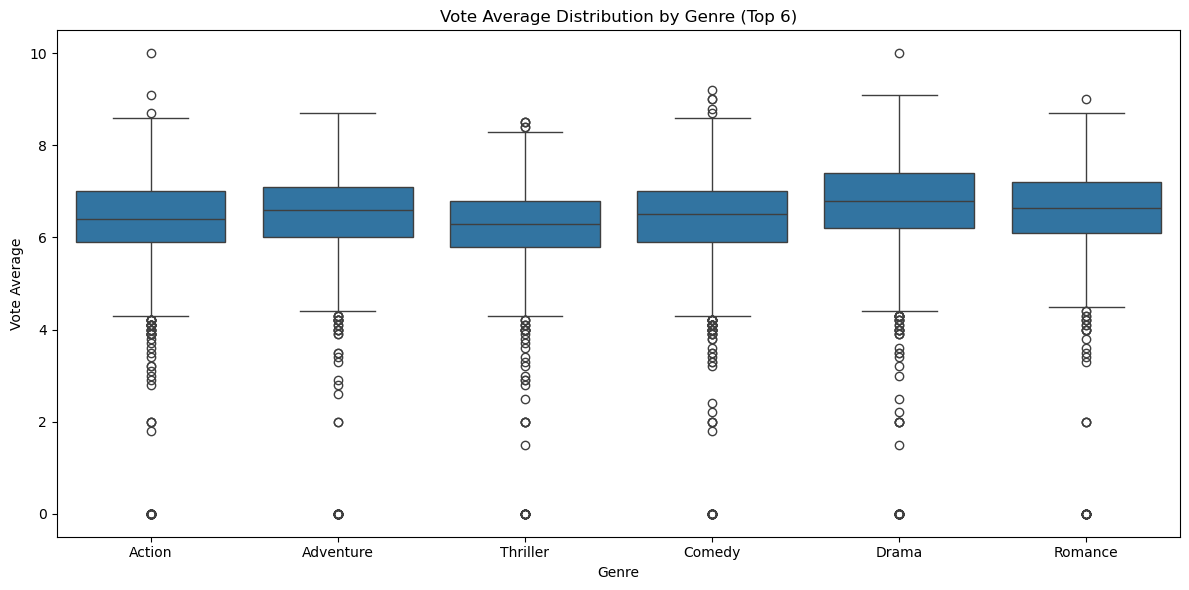

In [32]:
# Vote_Average distribution by top genres
top_genres = genre_df["Genre"].value_counts().head(6).index
filtered = genre_df[genre_df["Genre"].isin(top_genres)]

plt.figure(figsize=(12, 6))
sns.boxplot(x="Genre", y="Vote_Average", data=filtered)
plt.title("Vote Average Distribution by Genre (Top 6)")
plt.xlabel("Genre")
plt.ylabel("Vote Average")
plt.tight_layout()
plt.show()

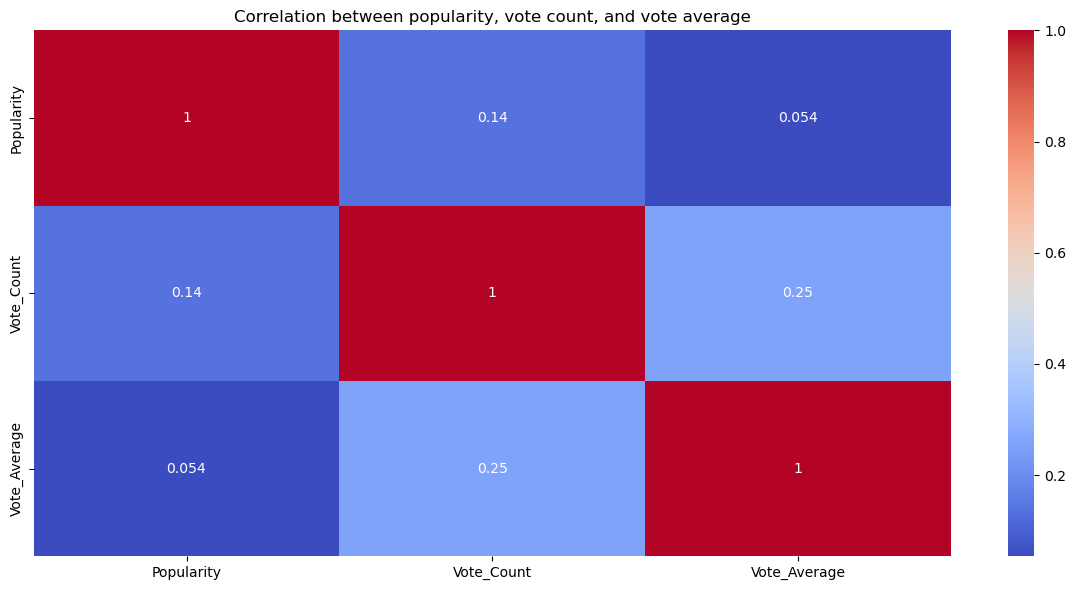

In [33]:
# Correlation between popularity, vote count, and vote average
corr_cols = ["Popularity", "Vote_Count", "Vote_Average"]
df[corr_cols] = df[corr_cols].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(12, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between popularity, vote count, and vote average")
plt.tight_layout()
plt.show()
